# Bibliotecas Usadas

In [955]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown

# Função para plotar gŕaficos, baseado em duas colunas de um DataFrame

In [956]:
def plotar(dataframe, linha, coluna1, coluna2, titulo, xlabel, ylabel, funcao_comparacao=None, tlabel=None):
    plt.figure()
    plt.plot(dataframe.loc[:linha, coluna1], dataframe.loc[:linha, coluna2], label="Dados Experimentais")
    if funcao_comparacao:
        x = dataframe.loc[:linha, coluna1]
        y_comparacao = funcao_comparacao(x)
        plt.plot(x, y_comparacao, label=tlabel, linestyle="--")
        plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(titulo)
    plt.grid(True)
    plt.show()

# Extração do dados de benchmark

In [957]:
df = pd.read_csv("resultados_benchmark.csv")
df

,idx,algoritmo,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_execucao_find,tempo_execucao_union,tempo_sort,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,1,prim,10,9,0.200000,9,0,0,0.0,0.0,0.000000,9,9,0.000003,9,0.000019
1,2,kruskal,10,9,0.200000,9,18,9,0.0,0.0,0.000002,0,0,0.000000,9,0.000024
2,3,prim,10,9,0.200000,9,0,0,0.0,0.0,0.000000,9,9,0.000001,9,0.000010
3,4,kruskal,10,9,0.200000,9,18,9,0.0,0.0,0.000001,0,0,0.000000,9,0.000016
4,5,prim,10,14,0.311111,9,0,0,0.0,0.0,0.000000,14,10,0.000002,9,0.000011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,716,kruskal,200,17907,0.899849,624,1248,199,0.0,0.0,0.001460,0,0,0.000000,199,0.007576
716,717,prim,200,19900,1.000000,199,0,0,0.0,0.0,0.000000,19900,619,0.002104,199,0.005173
717,718,kruskal,200,19900,1.000000,663,1326,199,0.0,0.0,0.001608,0,0,0.000000,199,0.008772
718,719,prim,200,19900,1.000000,199,0,0,0.0,0.0,0.000000,19900,453,0.002095,199,0.005157


# Extração e análise dos dados do algoritmo Prim

## Extração dos dados do Prim e eliminação das colunas que não representam o algoritmo

In [958]:
df_prim = df[df["algoritmo"] == "prim"]
df_prim = df_prim.drop(columns=["algoritmo", "find_calls", "union_calls", "tempo_execucao_find", "tempo_execucao_union", "tempo_sort"])

## Modificação dos índices do DataFrame para melhorar a filtragem

In [959]:
df_prim.reset_index(drop=True, inplace=True)
df_prim.head(10)

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,1,10,9,0.200000,9,9,9,0.000003,9,0.000019
1,3,10,9,0.200000,9,9,9,0.000001,9,0.000010
2,5,10,14,0.311111,9,14,10,0.000002,9,0.000011
3,7,10,10,0.222222,7,10,7,0.000001,7,0.000009
4,9,10,14,0.311111,9,14,9,0.000002,9,0.000010
5,11,10,16,0.355556,9,16,11,0.000002,9,0.000011
6,13,10,20,0.444444,9,20,17,0.000002,9,0.000013
7,15,10,26,0.577778,9,26,11,0.000004,9,0.000016
8,17,10,24,0.533333,9,24,15,0.000003,9,0.000014
9,19,10,19,0.422222,9,19,12,0.000002,9,0.000012


In [960]:
np.array([0.0]) + np.arange(0.3, 1.1, 0.1)

array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

## Análise do algoritmo Prim com o aumento dos vertices

### Para melhor caso (grafo é uma AGM)

In [961]:
df_prim_vertice_melhor = df_prim.loc[df_prim["num_vertices"] == (df_prim["num_arestas"] + 1)]
df_prim_vertice_melhor.drop_duplicates(subset="num_vertices", keep="first", inplace=True)
df_prim_vertice_melhor.sort_values(by="num_vertices", inplace=True)
df_prim_vertice_melhor.reset_index(drop=True, inplace=True)
df_prim_vertice_melhor.head(10)

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,1,10,9,0.200000,9,9,9,0.000003,9,0.000019
1,37,20,19,0.100000,19,19,19,0.000002,19,0.000014
2,73,30,29,0.066667,29,29,29,0.000002,29,0.000019
3,109,40,39,0.050000,39,39,39,0.000003,39,0.000022
4,145,50,49,0.040000,49,49,49,0.000004,49,0.000028
5,181,60,59,0.033333,59,59,59,0.000005,59,0.000033
6,217,70,69,0.028571,69,69,69,0.000005,69,0.000036
7,253,80,79,0.025000,79,79,79,0.000006,79,0.000042
8,289,90,89,0.022222,89,89,89,0.000007,89,0.000047
9,325,100,99,0.020000,99,99,99,0.000007,99,0.000052


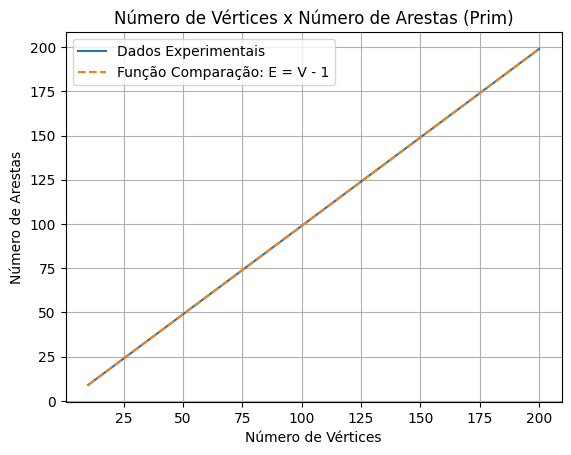

In [962]:
plotar(
    df_prim_vertice_melhor,
    linha=df_prim_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="num_arestas",
    titulo="Número de Vértices x Número de Arestas (Prim)",
    xlabel="Número de Vértices",
    ylabel="Número de Arestas",
    funcao_comparacao= lambda x : x - 1,
    tlabel="Função Comparação: E = V - 1"
)

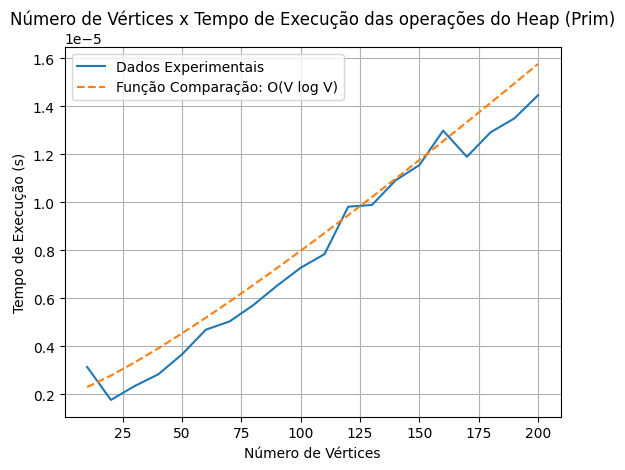

In [963]:
plotar(
    df_prim_vertice_melhor,
    linha=df_prim_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_heap_ops",
    titulo="Número de Vértices x Tempo de Execução das operações do Heap (Prim)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao= lambda x : 9e-9 * x * np.log2(x) + 0.000002,
    tlabel="Função Comparação: O(V log V)"
)

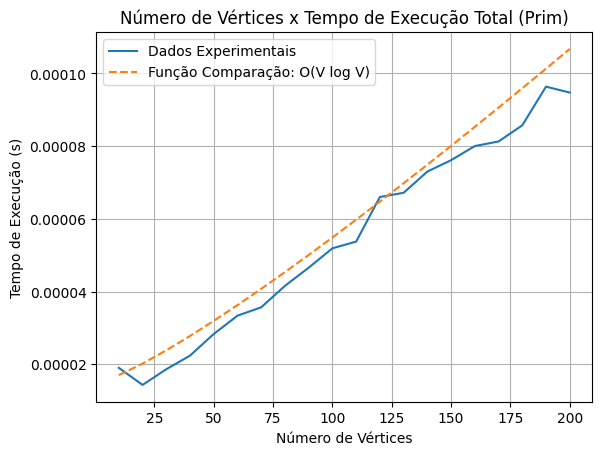

In [964]:
plotar(
    df_prim_vertice_melhor,
    linha=df_prim_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Prim)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao= lambda x : 6e-8 * x * np.log2(x) + 0.000015,
    tlabel="Função Comparação: O(V log V)"
)

### Conclusão
Para o melhor caso, o algortimo Prim possui complexidade $O(V \log V)$, possui nesse caso $E = V -1 $. Isso é refletido no tempo de execução do Heap,

### Para o pior caso, grafos densos

In [965]:
df_prim_vertice_pior = df_prim.sort_values(by="densidade", ascending=False)
df_prim_vertice_pior.drop_duplicates(subset="num_vertices", keep="first", inplace=True)
df_prim_vertice_pior.sort_values(by="num_vertices", inplace=True)
df_prim_vertice_pior.reset_index(drop=True, inplace=True)
df_prim_vertice_pior

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,33,10,45,1.0,9,45,10,0.000005,9,0.000019
1,71,20,190,1.0,19,190,34,0.000021,19,0.000058
2,105,30,435,1.0,29,435,31,0.000045,29,0.000108
3,141,40,780,1.0,39,780,103,0.000082,39,0.000209
4,177,50,1225,1.0,49,1225,121,0.000125,49,0.000315
5,213,60,1770,1.0,59,1770,160,0.000181,59,0.000439
6,251,70,2415,1.0,69,2415,126,0.000252,69,0.000597
7,285,80,3160,1.0,79,3160,136,0.000341,79,0.000804
8,321,90,4005,1.0,89,4005,200,0.000429,89,0.001027
9,359,100,4950,1.0,99,4950,237,0.000509,99,0.001171


Fixando a densidade em 1.0, as arestas serão encontradas por $E = V \cdot (V -1)$

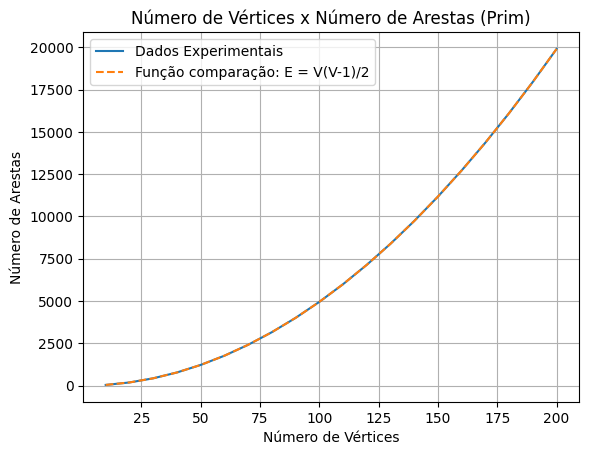

In [966]:
plotar(
    df_prim_vertice_pior,
    linha=df_prim_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="num_arestas",
    titulo="Número de Vértices x Número de Arestas (Prim)",
    xlabel="Número de Vértices",
    ylabel="Número de Arestas",
    funcao_comparacao=lambda x : (x * (x - 1)) / 2, # No pior caso, um grafo completo tem E = V(V-1)/2
    tlabel="Função comparação: E = V(V-1)/2"
)

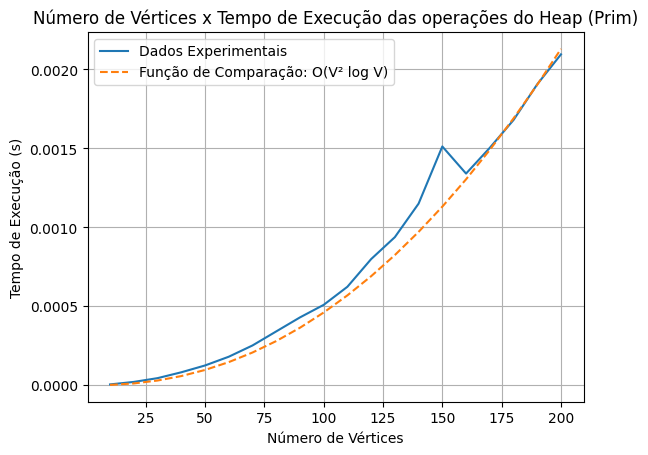

In [967]:
plotar(
    df_prim_vertice_pior,
    linha=df_prim_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_heap_ops",
    titulo="Número de Vértices x Tempo de Execução das operações do Heap (Prim)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao=lambda x : 7e-9 * (x*(x-1)) * np.log2(x),
    tlabel="Função de Comparação: O(V² log V)"
)

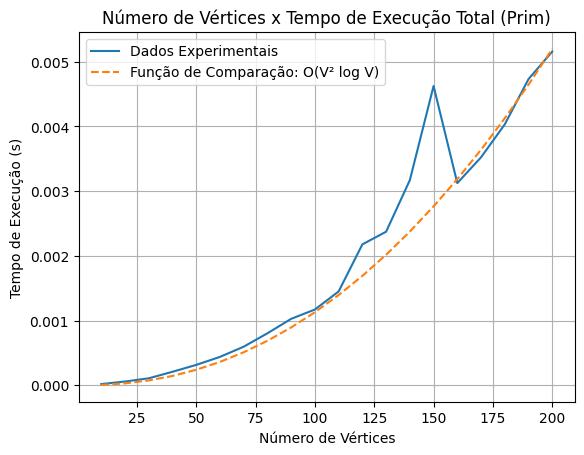

In [968]:
plotar(
    df_prim_vertice_pior,
    linha=df_prim_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Prim)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao=lambda x : 17e-9 * (x**2) * np.log2(x),
    tlabel="Função de Comparação: O(V² log V)"
)

### Conclusão
Ao se fixar a densidado, as arestas aumentam em $O(V²)$, assim a complexidade do Prim, dado por $O(E \log{V})$, transforma-se em $O(V^2 \log{V})$. Isso é refletido no tempo de execução total e no tempo de execução das operações do Heap, no pior caso.

## Análise do algorimto Prim com o aumento do número de arestas do grafo

In [969]:
df_prim_arestas = df_prim.sort_values(by="densidade")
maior_num_vertice = df_prim_arestas["num_vertices"].max()
df_prim_arestas = df_prim_arestas[df_prim_arestas["num_vertices"] == maior_num_vertice]
df_prim_arestas.drop_duplicates(subset="densidade", keep="first", inplace=True)
df_prim_arestas.reset_index(drop=True, inplace=True)
df_prim_arestas

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,687,200,199,0.010000,199,199,199,0.000014,199,0.000093
1,691,200,5874,0.295176,199,5874,508,0.000603,199,0.001530
2,689,200,6062,0.304623,199,6062,497,0.000633,199,0.001583
3,693,200,7915,0.397739,199,7915,484,0.000823,199,0.001988
4,695,200,7927,0.398342,199,7927,471,0.000838,199,0.001991
5,699,200,9888,0.496884,199,9888,632,0.001038,199,0.002541
6,697,200,10019,0.503467,199,10019,1084,0.001047,199,0.002673
7,701,200,11937,0.599849,199,11937,485,0.001309,199,0.003135
8,703,200,11959,0.600955,199,11959,633,0.001251,199,0.003021
9,705,200,13908,0.698894,199,13908,486,0.001442,199,0.003461


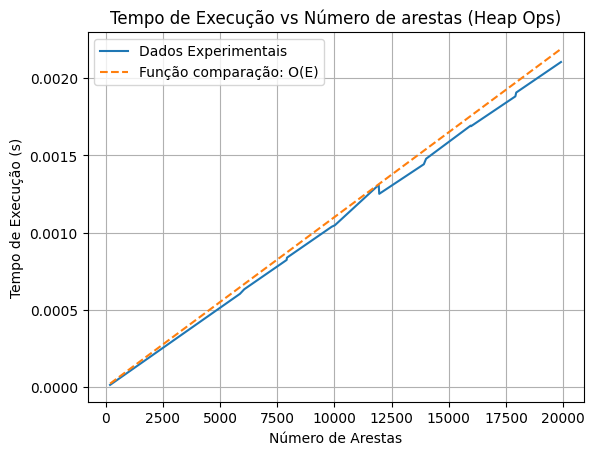

In [970]:
plotar(
    df_prim_arestas,
    linha=df_prim_arestas.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_heap_ops",
    titulo="Tempo de Execução vs Número de arestas (Heap Ops)",
    xlabel="Número de Arestas",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao= lambda x : 11e-8 * x,
    tlabel="Função comparação: O(E)"
)

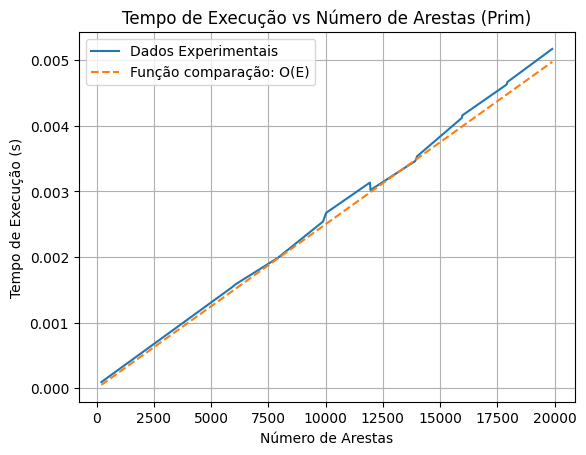

In [971]:
plotar(
    df_prim_arestas,
    linha=df_prim_arestas.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_total",
    titulo="Tempo de Execução vs Número de Arestas (Prim)",
    xlabel="Número de Arestas",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao= lambda x : 25e-8 * x,
    tlabel="Função comparação: O(E)"
)

### Conclusão
Ao fixar os vértices, a complexidade do Prim aumente pela função O(E), e visto que a densidade é proporcional ao número de arestas, pode-se dizer que o aumento da densidade resulta no aumento linear do tempo de execução

## Comparação do tempo gasto pelas operações do heap com o tempo gasto na totalidade

In [972]:
df_prim_copia = df_prim.copy()
df_prim_copia["porcentagem_heap_ops"] = (df_prim_copia["tempo_execucao_heap_ops"] / df_prim_copia["tempo_execucao_total"]) * 100
df_prim_copia

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total,porcentagem_heap_ops
0,1,10,9,0.200000,9,9,9,0.000003,9,0.000019,16.497519
1,3,10,9,0.200000,9,9,9,0.000001,9,0.000010,11.785424
2,5,10,14,0.311111,9,14,10,0.000002,9,0.000011,16.416151
3,7,10,10,0.222222,7,10,7,0.000001,7,0.000009,15.322316
4,9,10,14,0.311111,9,14,9,0.000002,9,0.000010,17.094632
...,...,...,...,...,...,...,...,...,...,...,...
355,711,200,15968,0.802412,199,15968,493,0.001689,199,0.004158,40.605902
356,713,200,17945,0.901759,199,17945,368,0.001907,199,0.004669,40.839963
357,715,200,17907,0.899849,199,17907,699,0.001882,199,0.004630,40.647775
358,717,200,19900,1.000000,199,19900,619,0.002104,199,0.005173,40.680172


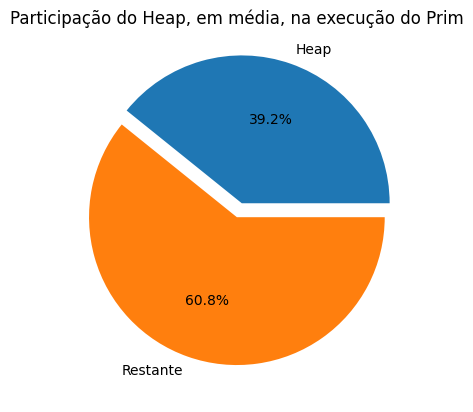

In [973]:
tempo_heap = df_prim["tempo_execucao_heap_ops"].mean()
tempo_total = df_prim["tempo_execucao_total"].mean()
tempo_resto = tempo_total - tempo_heap

plt.figure()
plt.pie(
    [tempo_heap, tempo_resto],
    labels=["Heap", "Restante"],
    autopct="%1.1f%%",
    explode=[0.1, 0]
)
plt.title("Participação do Heap, em média, na execução do Prim")
plt.show()

### Conclusão
O tempo gasto nas operações do heap equivale, em média, a 40% do total do tempo de execução, evidenciando que o heap constitui uma parte significativa do tempo

## Conclusão Sobre o algoritmo de Prim
O algoritmo de Prim possui um melhor caso como $O(V \log V)$, um caso médio como $O(E \log V)$ e um pior caso como $O(V² \log V)$. Fortemente influênciado pela quantidade de vértices

# Extração e análise dos dados do algoritmo Kruskal

In [974]:
df_kruskal = df[df["algoritmo"] == "kruskal"]
df_kruskal.drop(columns=["algoritmo", "heap_push", "heap_pop", "tempo_execucao_heap_ops", "tempo_execucao_find", "tempo_execucao_union"], inplace=True)

## Modificação dos índices do DataFrame para melhorar a filtragem

In [975]:
df_kruskal.reset_index(drop=True, inplace=True)
df_kruskal.head(10)

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_sort,num_arestas_mst,tempo_execucao_total
0,2,10,9,0.200000,9,18,9,0.000002,9,0.000024
1,4,10,9,0.200000,9,18,9,0.000001,9,0.000016
2,6,10,14,0.311111,10,20,9,0.000002,9,0.000017
3,8,10,10,0.222222,7,14,7,0.000001,7,0.000014
4,10,10,14,0.311111,9,18,9,0.000002,9,0.000016
5,12,10,16,0.355556,11,22,9,0.000002,9,0.000018
6,14,10,20,0.444444,17,34,9,0.000002,9,0.000020
7,16,10,26,0.577778,11,22,9,0.000002,9,0.000021
8,18,10,24,0.533333,15,30,9,0.000002,9,0.000023
9,20,10,19,0.422222,12,24,9,0.000002,9,0.000019


- Aumento de vértice x (find_calls, union_calls, tempo_execucao_total)
- Aumento da densidade x (find_calls, union_calls, tempo_execucao_total)
- pizza (tempo union, tempo sort, tempo total)

## Análise do Kruskal em relação ao aumento do número de vértices

### Melhor caso (grafo é uma árvore geradora mínima)

In [976]:
df_kruskal_vertice_melhor = df_kruskal.loc[df_kruskal["num_vertices"] == (df_kruskal["num_arestas"] + 1)]
df_kruskal_vertice_melhor.drop_duplicates(subset="num_vertices", keep="first", inplace=True)
df_kruskal_vertice_melhor.sort_values(by="num_vertices", inplace=True)
df_kruskal_vertice_melhor.reset_index(drop=True, inplace=True)
df_kruskal_vertice_melhor.head(10)

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_sort,num_arestas_mst,tempo_execucao_total
0,2,10,9,0.200000,9,18,9,0.000002,9,0.000024
1,38,20,19,0.100000,19,38,19,0.000001,19,0.000024
2,74,30,29,0.066667,29,58,29,0.000002,29,0.000032
3,110,40,39,0.050000,39,78,39,0.000002,39,0.000038
4,146,50,49,0.040000,49,98,49,0.000002,49,0.000046
5,182,60,59,0.033333,59,118,59,0.000003,59,0.000052
6,218,70,69,0.028571,69,138,69,0.000002,69,0.000059
7,254,80,79,0.025000,79,158,79,0.000003,79,0.000068
8,290,90,89,0.022222,89,178,89,0.000003,89,0.000074
9,326,100,99,0.020000,99,198,99,0.000003,99,0.000092


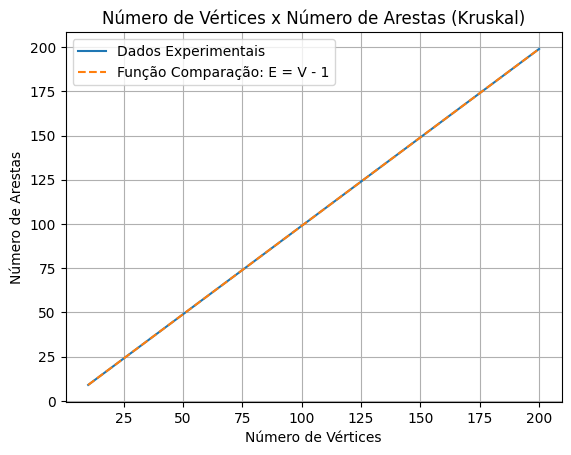

In [977]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="num_arestas",
    titulo="Número de Vértices x Número de Arestas (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Arestas",
    funcao_comparacao= lambda x : x - 1,
    tlabel="Função Comparação: E = V - 1"
)

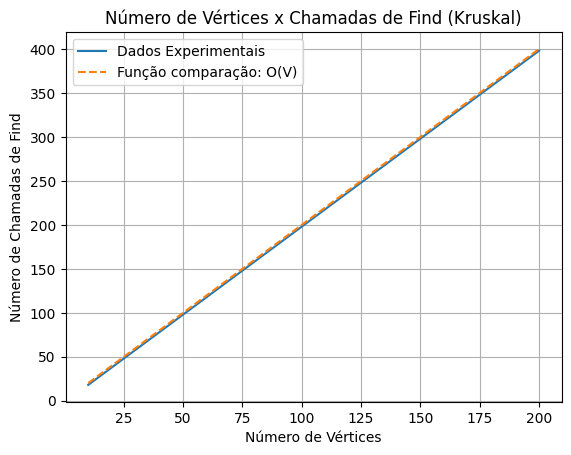

In [978]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="find_calls",
    titulo="Número de Vértices x Chamadas de Find (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Chamadas de Find",
    funcao_comparacao= lambda x: 2 * x,
    tlabel="Função comparação: O(V)"
)

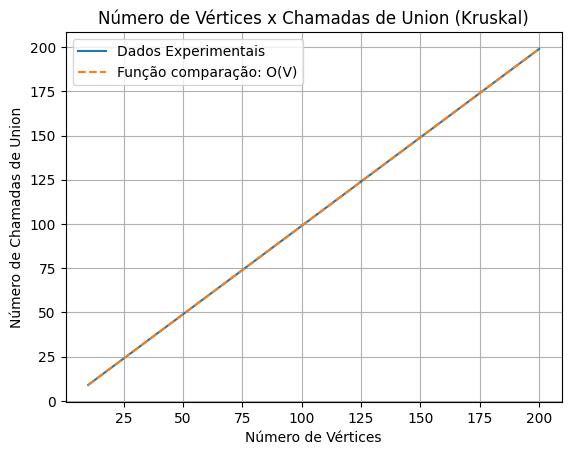

In [979]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="union_calls",
    titulo="Número de Vértices x Chamadas de Union (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Chamadas de Union",
    funcao_comparacao=lambda x: x - 1,
    tlabel="Função comparação: O(V)"
)

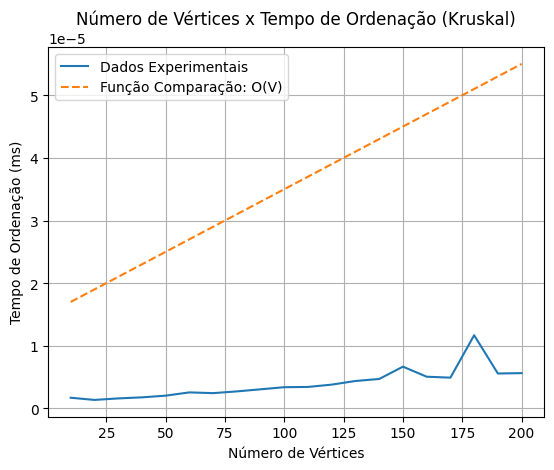

In [980]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_sort",
    titulo="Número de Vértices x Tempo de Ordenação (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Ordenação (ms)",
    funcao_comparacao= lambda x : 20e-8 * x + 0.000015 ,
    tlabel="Função Comparação: O(V)"
)

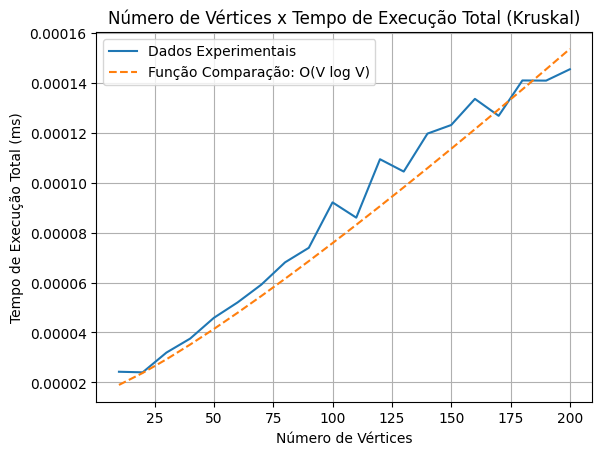

In [981]:
plotar(
    df_kruskal_vertice_melhor,
    linha=df_kruskal_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Total (ms)",
    funcao_comparacao= lambda x : 9e-8 * x * np.log2(x) + 0.000016,
    tlabel="Função Comparação: O(V log V)"
)

### Conclusão
A complexidade o algoritmo torna-se $O(V \log V)$ no melhor caso. O número de chamadas de Find cresce linearmente, pois o número de chamadas do union sempre será o número de arestas ad AGM, que é $V -1 $. Nesse caso, haverá uma razão entre o número de chamadas do Union e o número de chamadas do Find, tendendo ao 0.25. Segue tabelas de comparação:

Também é interessante notar que mesmo que o tempo de execução do find e do union são lineares, pois operações envonvendo conjunto são lineares assintoticamente, ou seja tornam-se O(E), que no melhor caso fica O(V). Outro fator importante é que a função de ordenação usada é o TimSort, nativo do python, que em seu melhor caso gera complexidade O(n), no nosso caso, O(V)

In [982]:
table = df_kruskal_vertice_melhor[["num_vertices", "num_arestas", "find_calls", "union_calls"]]
table["razão (Union/Find)"] = table["union_calls"] / table["find_calls"]
display(Markdown("### Tabela de Chamadas de Find e Union (Kruskal) para melhor caso"))
display(table)

### Tabela de Chamadas de Find e Union (Kruskal) para melhor caso

,num_vertices,num_arestas,find_calls,union_calls,razão (Union/Find)
0,10,9,18,9,0.5
1,20,19,38,19,0.5
2,30,29,58,29,0.5
3,40,39,78,39,0.5
4,50,49,98,49,0.5
5,60,59,118,59,0.5
6,70,69,138,69,0.5
7,80,79,158,79,0.5
8,90,89,178,89,0.5
9,100,99,198,99,0.5


### Pior caso (Árvore Densa)

In [983]:
df_kruskal_vertice_pior = df_kruskal.sort_values(by="densidade", ascending=False)
df_kruskal_vertice_pior.drop_duplicates(subset="num_vertices", keep="first", inplace=True)
df_kruskal_vertice_pior.sort_values(by="num_vertices", inplace=True)
df_kruskal_vertice_pior.reset_index(drop=True, inplace=True)
df_kruskal_vertice_pior

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_sort,num_arestas_mst,tempo_execucao_total
0,34,10,45,1.0,10,20,9,0.000004,9,0.000030
1,72,20,190,1.0,33,66,19,0.000014,19,0.000094
2,106,30,435,1.0,33,66,29,0.000031,29,0.000171
3,142,40,780,1.0,105,210,39,0.000061,39,0.000331
4,178,50,1225,1.0,118,236,49,0.000105,49,0.000479
5,214,60,1770,1.0,166,332,59,0.000143,59,0.000662
6,252,70,2415,1.0,108,216,69,0.000190,69,0.000910
7,286,80,3160,1.0,146,292,79,0.000264,79,0.001245
8,322,90,4005,1.0,198,396,89,0.000330,89,0.001516
9,360,100,4950,1.0,251,502,99,0.000387,99,0.001767


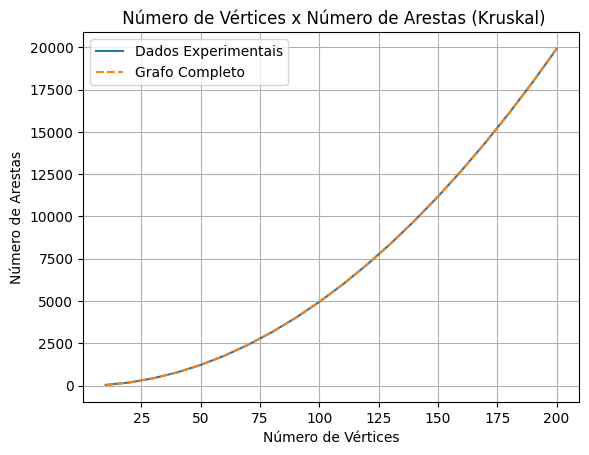

In [984]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="num_arestas",
    titulo=" Número de Vértices x Número de Arestas (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Arestas",
    funcao_comparacao=lambda x : (x * (x - 1)) / 2, # No pior caso, um grafo completo tem E = V(V-1)/2
    tlabel="Grafo Completo"
)

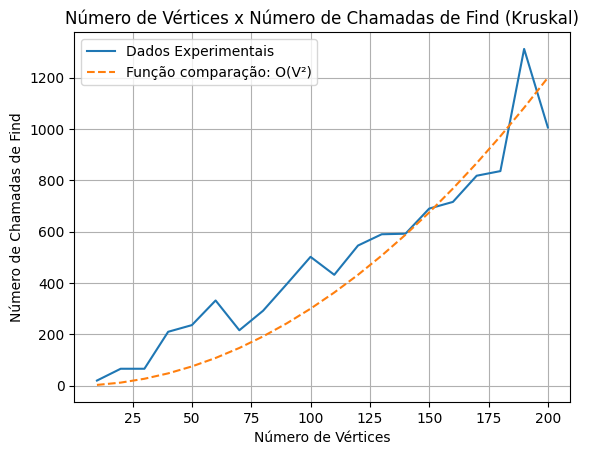

In [985]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="find_calls",
    titulo="Número de Vértices x Número de Chamadas de Find (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Chamadas de Find",
    funcao_comparacao=lambda x : 30e-3 * x**2, #No pior caso o número de chamadas é O(V²)
    tlabel="Função comparação: O(V²)"
)

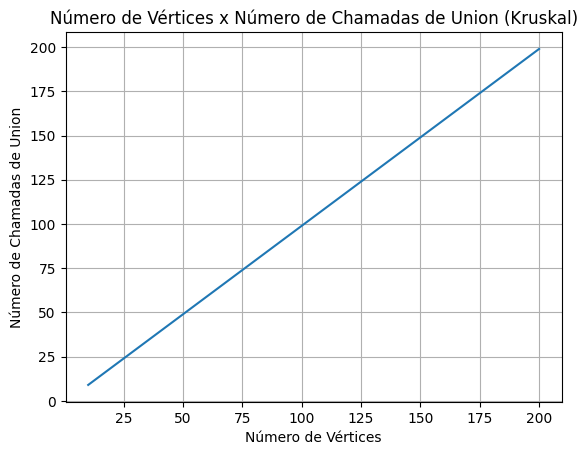

In [986]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="union_calls",
    titulo="Número de Vértices x Número de Chamadas de Union (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Número de Chamadas de Union"
)

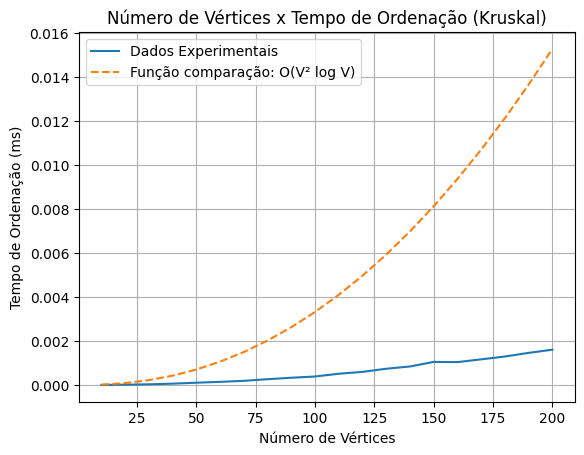

In [987]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_sort",
    titulo="Número de Vértices x Tempo de Ordenação (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Ordenação (ms)",
    funcao_comparacao=lambda x : 5e-8 * x**2 * np.log2(x),
    tlabel="Função comparação: O(V² log V)"
)

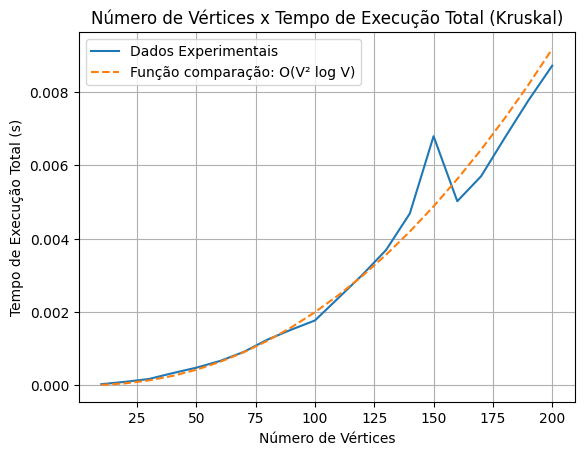

In [988]:
plotar(
    df_kruskal_vertice_pior,
    linha=df_kruskal_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Kruskal)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Total (s)",
    funcao_comparacao=lambda x: 3e-8 * x**2 * np.log2(x),
    tlabel="Função comparação: O(V² log V)"
)

### Conclusão
O tempo de ordenação é $O(E \log E)$, que no pior caso se torna, $O(V² \log V)$. Os tempos de execução do find e do union são lineares em relação à |E|, assim tornam-se quadráticos em relação à V. A complexidade do Kruskal é $O(V² \log V)$ no pior caso.

## Análise do algorimto Kruskal com o aumento do número de arestas do grafo

In [989]:
df_kruskal_densidade = df_kruskal.sort_values(by="densidade")
maior_num_vertice = df_kruskal_densidade["num_vertices"].max()
df_kruskal_densidade = df_kruskal_densidade[df_kruskal_densidade["num_vertices"] == maior_num_vertice]
df_kruskal_densidade.drop_duplicates(subset="densidade", keep="first", inplace=True)
df_kruskal_densidade.reset_index(drop=True, inplace=True)
df_kruskal_densidade

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_sort,num_arestas_mst,tempo_execucao_total
0,688,200,199,0.010000,199,398,199,0.000005,199,0.000143
1,692,200,5874,0.295176,522,1044,199,0.000463,199,0.002219
2,690,200,6062,0.304623,473,946,199,0.000475,199,0.002277
3,694,200,7915,0.397739,491,982,199,0.000628,199,0.002904
4,696,200,7927,0.398342,440,880,199,0.000622,199,0.002907
5,700,200,9888,0.496884,654,1308,199,0.000786,199,0.003719
6,698,200,10019,0.503467,1096,2192,199,0.000807,199,0.003862
7,702,200,11937,0.599849,467,934,199,0.000981,199,0.005421
8,704,200,11959,0.600955,619,1238,199,0.000956,199,0.004566
9,706,200,13908,0.698894,551,1102,199,0.001128,199,0.005403


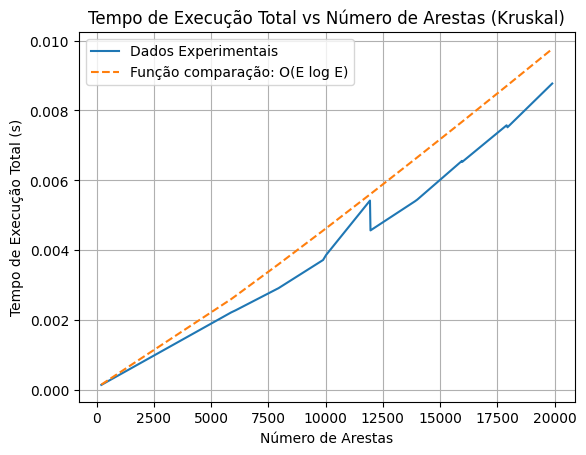

In [990]:
plotar(
    df_kruskal_densidade,
    linha=df_kruskal_densidade.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_total",
    titulo="Tempo de Execução Total vs Número de Arestas (Kruskal)",
    xlabel="Número de Arestas",
    ylabel="Tempo de Execução Total (s)",
    funcao_comparacao=lambda x : 34e-9 * x * np.log2(x) + 0.0001,
    tlabel="Função comparação: O(E log E)"
)

### Conclusão
Para o mesmo número de vértices, o aumento da densidade (número de arestas) corresponde a um aumento linear dos tempos de execução das operações de conjunto enquanto a ordenação cresce em ordem superlinear (E log E)

## Comparação entre o tempo gasto pelas operações de conjunto, pelo ordenação e o total

In [991]:
df_kruskal_comparacao = df_kruskal[["num_vertices", "num_arestas", "tempo_sort", "tempo_execucao_total"]]
df_kruskal_comparacao.head(10)

,num_vertices,num_arestas,tempo_sort,tempo_execucao_total
0,10,9,0.000002,0.000024
1,10,9,0.000001,0.000016
2,10,14,0.000002,0.000017
3,10,10,0.000001,0.000014
4,10,14,0.000002,0.000016
5,10,16,0.000002,0.000018
6,10,20,0.000002,0.000020
7,10,26,0.000002,0.000021
8,10,24,0.000002,0.000023
9,10,19,0.000002,0.000019


In [993]:
df_kruskal_comparacao.loc[df_kruskal_comparacao["tempo_sort"] > df_kruskal_comparacao["tempo_execucao_total"]]

,num_vertices,num_arestas,tempo_sort,tempo_execucao_total


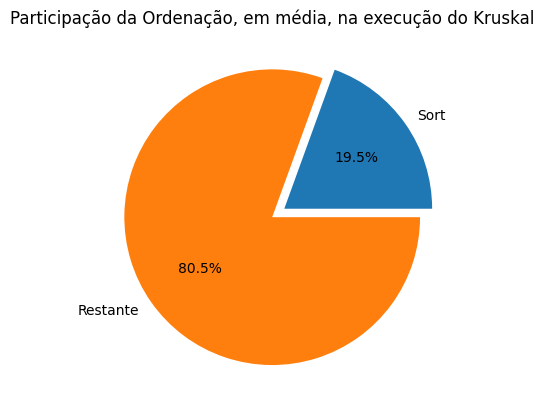

In [994]:
tempo_total = df_kruskal_comparacao["tempo_execucao_total"].mean()
tempo_sort = df_kruskal_comparacao["tempo_sort"].mean()
tempo_resto = tempo_total - tempo_sort

plt.figure()
plt.pie(
    [tempo_sort, tempo_resto],
    labels=["Sort", "Restante"],
    autopct="%1.1f%%",
    explode=[0.1,  0]
)
plt.title("Participação da Ordenação, em média, na execução do Kruskal")
plt.show()

## Conclusão
O gráfico mostra que a ordenação compõe um tempo de 20% do tempo total do Kruskal

# Comparações entre algortimos
retire os resultados diretamente aqui

In [995]:
def plotar_comparacao(dataframe1, dataframe2, linha, coluna1, coluna2, titulo, xlabel, ylabel):
    plt.figure()
    plt.plot(dataframe1.loc[:linha, coluna1], dataframe1.loc[:linha, coluna2], label="Prim")
    plt.plot(dataframe2.loc[:linha, coluna1], dataframe2.loc[:linha, coluna2], label="Kruskal")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(titulo)
    plt.grid(True)
    plt.legend()
    plt.show()

# Melhor caso para densidade constante

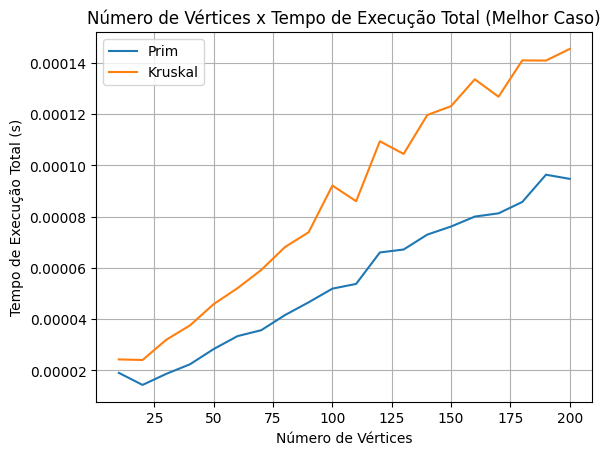

In [996]:
plotar_comparacao(
    df_prim_vertice_melhor,
    df_kruskal_vertice_melhor,
    linha=df_prim_vertice_melhor.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Melhor Caso)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Total (s)"
)

## Pior caso para densidade constante

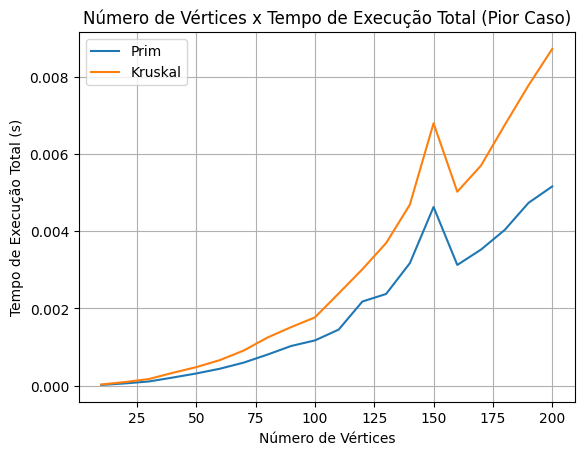

In [997]:
plotar_comparacao(
    df_prim_vertice_pior,
    df_kruskal_vertice_pior,
    linha=df_prim_vertice_pior.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Pior Caso)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Total (s)"
)

## Vértices constantes

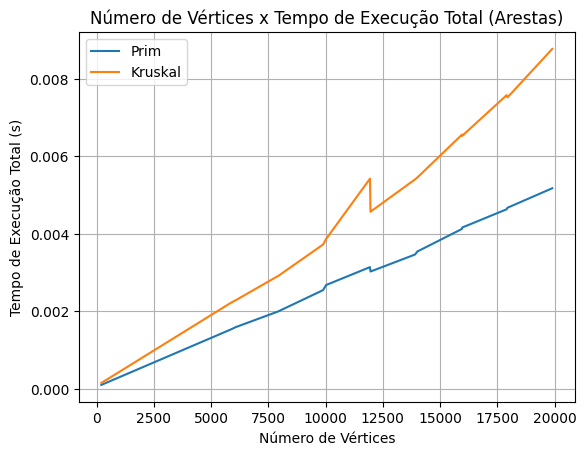

In [998]:
plotar_comparacao(
    df_prim_arestas,
    df_kruskal_densidade,
    linha=df_prim_arestas.shape[0] - 1,
    coluna1="num_arestas",
    coluna2="tempo_execucao_total",
    titulo="Número de Vértices x Tempo de Execução Total (Arestas)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução Total (s)"
)